In [8]:
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [9]:
label = LabelEncoder()

data = pd.read_csv("C:\\Users\\sulem\\OneDrive\\Desktop\\Codes\\ML\\Datasets\\Mall_Customers.csv")

def ColumnTransformation(data):

    data["Gender"] = label.fit_transform(data["Gender"])
    data = data.drop(columns=["CustomerID"])
    return data

Data = ColumnTransformation(data)
Data.sample(10)

Gender  Age  Annual Income (k$)  Spending Score (1-100)
25        1   29                  28                      82
55        1   47                  43                      41
197       1   32                 126                      74
192       1   33                 113                       8
170       1   40                  87                      13
54        0   50                  43                      45
100       0   23                  62                      41
169       1   32                  87                      63
68        1   19                  48                      59
36        0   42                  34                      17

[308862.06000000006, 212889.44245524294, 143391.5923603568, 104414.67534220168, 75399.61541401484, 58348.64136331505, 51132.7032125769, 44687.235534005464, 40655.68621378622, 37549.03257298257, 34681.51156457921, 32313.764285714286, 29920.163864631537, 28524.302894368117, 26137.094070914463, 24807.975757575758, 22894.043888709326, 22086.908141451768]


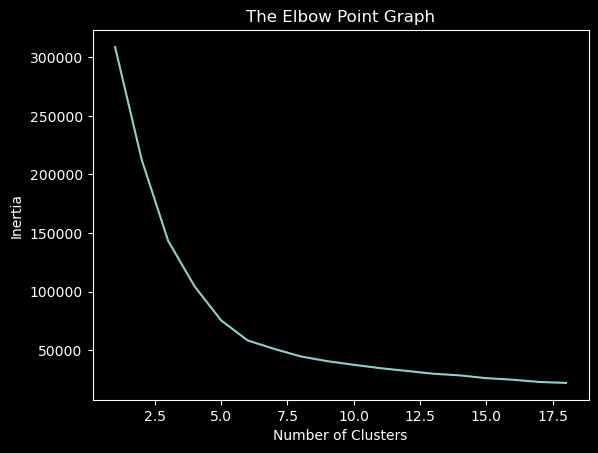

In [10]:
import warnings
warnings.filterwarnings('ignore')

inertia = []
for i in range(1,19):
    km = KMeans(n_clusters=i, n_init=10)
    km.fit_predict(Data) 
    inertia.append(km.inertia_)

print(inertia)

plt.plot(range(1,19), inertia)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0) # K = 5 from Elbow Curve

Y = kmeans.fit_predict(Data)

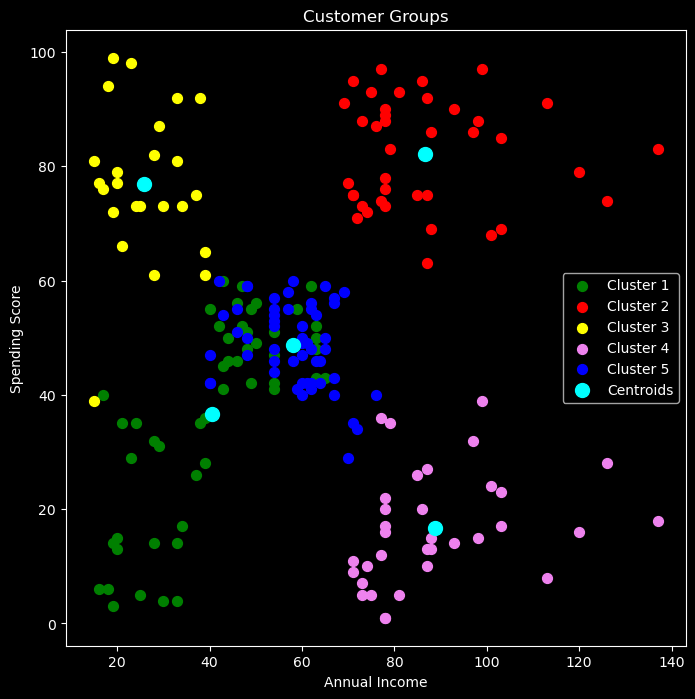

In [14]:
D = Data.values 

plt.figure(figsize=(8,8))
plt.scatter(D[Y==0, 2], D[Y==0, 3], s=50, c='green', label='Cluster 1')
plt.scatter(D[Y==1, 2], D[Y==1, 3], s=50, c='red', label='Cluster 2')
plt.scatter(D[Y==2, 2], D[Y==2, 3], s=50, c='yellow', label='Cluster 3')
plt.scatter(D[Y==3, 2], D[Y==3, 3], s=50, c='violet', label='Cluster 4')
plt.scatter(D[Y==4, 2], D[Y==4, 3], s=50, c='blue', label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:,2], kmeans.cluster_centers_[:,3], s=100, c='cyan', label='Centroids')

plt.title('Customer Groups')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()